# Week 3 · Time Series – Decomposition, ARIMA & Prophet
**Dataset:** Atmospheric CO₂ — Mauna Loa Observatory (statsmodels built-in)  
Monthly readings from 1958 to 2001. Clear upward trend + strong annual seasonality.

### What we cover
1. Load & visualise
2. Seasonal decomposition
3. Stationarity test + differencing
4. Lags
5. ACF & PACF
6. ARIMA — fit, forecast, evaluate
7. SARIMA — add seasonality
8. Prophet — fit, forecast, components
9. Model comparison


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.seasonal   import seasonal_decompose
from statsmodels.tsa.stattools  import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model   import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('All imports OK')

All imports OK


## 2. Load the CO₂ Dataset

In [21]:
# Built into statsmodels — no download needed
co2_raw = sm.datasets.co2.load_pandas().data
co2_raw = co2_raw.ffill()  # fill the few missing weeks
# Resample to monthly — cleaner for ARIMA and decomposition
co2 = co2_raw.resample('ME').mean()
co2.columns = ['co2']

print('Shape :', co2.shape)
print('Range :', co2.index[0].date(), 'to', co2.index[-1].date())
print()
co2.head(8)

Shape : (526, 1)
Range : 1958-03-31 to 2001-12-31



,co2
1958-03-31,316.100
1958-04-30,317.200
1958-05-31,317.420
1958-06-30,317.900
1958-07-31,315.625
1958-08-31,314.960
1958-09-30,313.500
1958-10-31,313.500


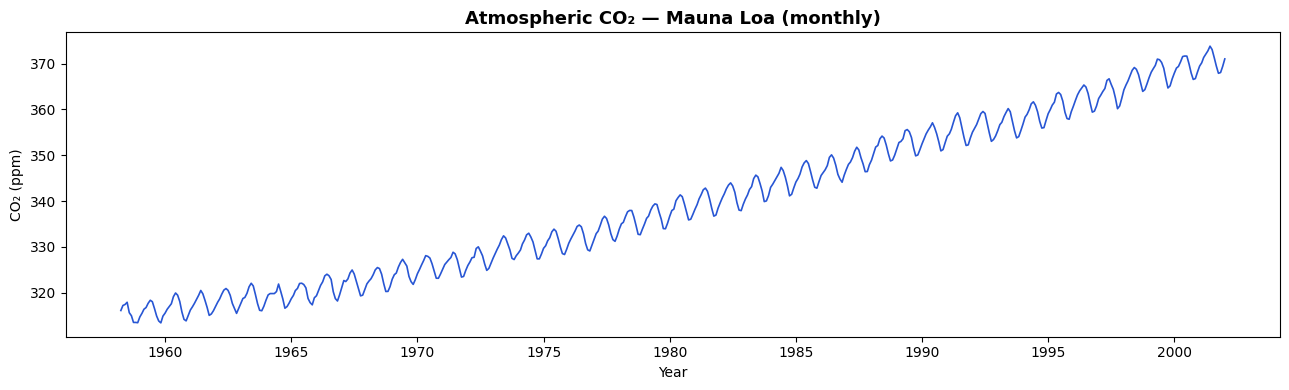

Observations:
  - Clear upward TREND over 40+ years
  - Repeating annual SEASONALITY (CO₂ dips in summer as plants absorb it)
  - Series is NOT stationary — mean increases over time


In [23]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(co2.index, co2['co2'], color='#2856d4', lw=1.2)
ax.set_title('Atmospheric CO₂ — Mauna Loa (monthly)', fontweight='bold', fontsize=13)
ax.set_ylabel('CO₂ (ppm)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

print('Observations:')
print('  - Clear upward TREND over 40+ years')
print('  - Repeating annual SEASONALITY (CO₂ dips in summer as plants absorb it)')
print('  - Series is NOT stationary — mean increases over time')

## 3. Seasonal Decomposition
Separate the series into its three components: trend, seasonality, and residual noise.
We use `period=12` because we have monthly data with annual seasonality.


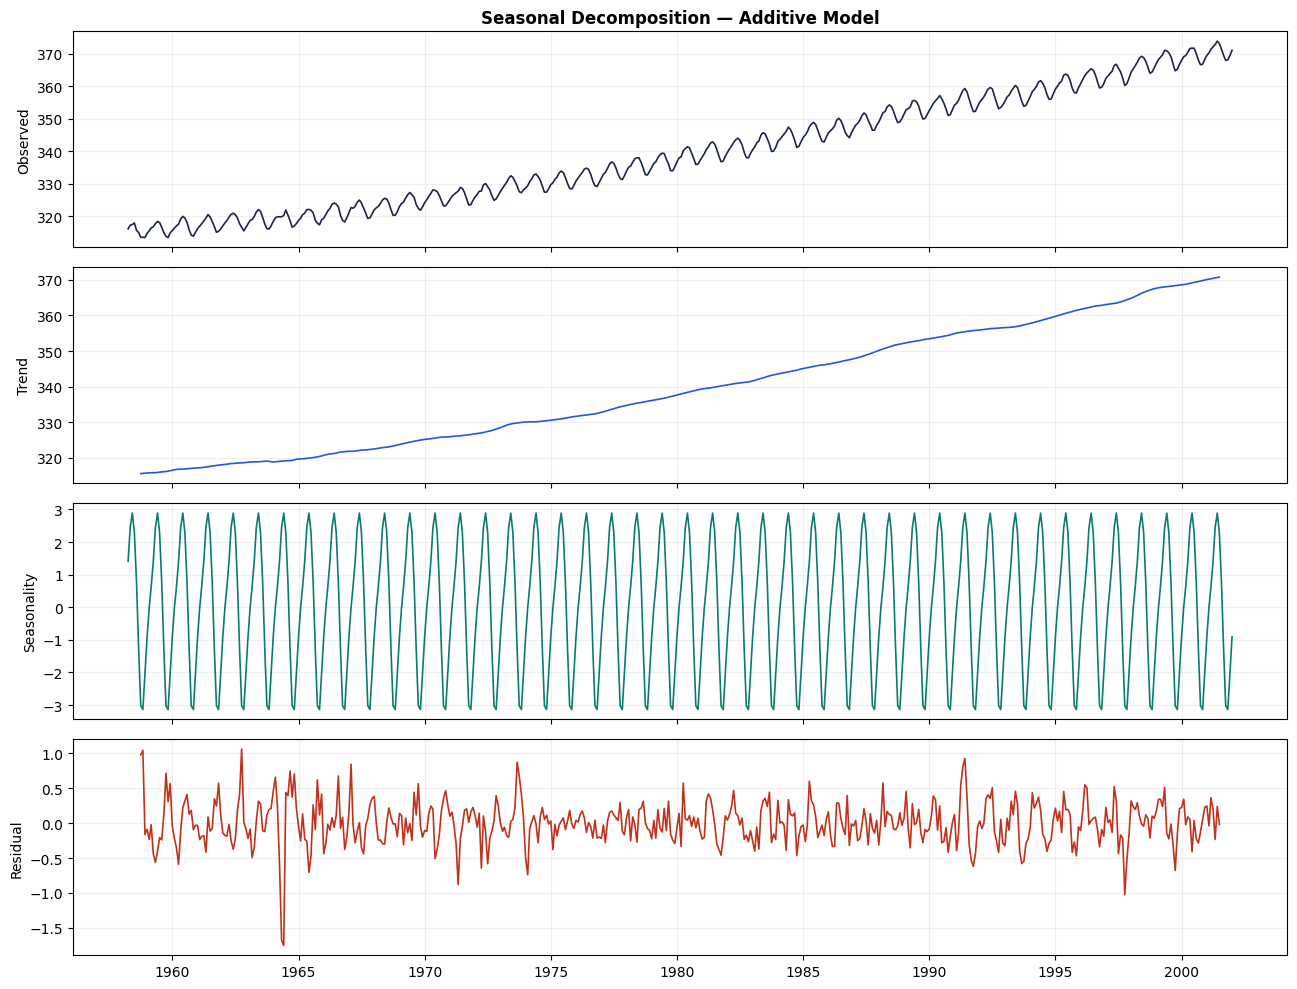

Trend: CO₂ rises ~1.4 ppm per year on average
Seasonal amplitude: 6.03 ppm
Residual std: 0.3093


In [4]:
result = seasonal_decompose(co2, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

components = [
    (co2['co2'],       'Observed',   '#1a2744'),
    (result.trend,     'Trend',      '#2856d4'),
    (result.seasonal,  'Seasonality','#0a7c6e'),
    (result.resid,     'Residual',   '#c0321b'),
]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data, color=color, lw=1.2)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.2)

axes[0].set_title('Seasonal Decomposition — Additive Model', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Trend: CO₂ rises ~1.4 ppm per year on average')
print('Seasonal amplitude:', round(result.seasonal.max() - result.seasonal.min(), 2), 'ppm')
print('Residual std:',       round(result.resid.dropna().std(), 4))

## 4. Stationarity — ADF Test & Differencing
ARIMA requires a stationary series. We use the ADF test to check,
then apply differencing until the series is stationary.


In [5]:
def adf_test(series, label='Series'):
    result = adfuller(series.dropna())
    print(f'{label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    verdict = 'STATIONARY ✓' if result[1] < 0.05 else 'NON-STATIONARY ✗ — need differencing'
    print(f'  Result        : {verdict}')
    print()

adf_test(co2['co2'],            'Raw CO₂ series')

co2_diff1 = co2['co2'].diff().dropna()
adf_test(co2_diff1,             '1st-order differenced')

co2_diff2 = co2_diff1.diff().dropna()
adf_test(co2_diff2,             '2nd-order differenced')

Raw CO₂ series
  ADF Statistic : 2.1401
  p-value       : 0.9988
  Result        : NON-STATIONARY ✗ — need differencing

1st-order differenced
  ADF Statistic : -4.8247
  p-value       : 0.0000
  Result        : STATIONARY ✓

2nd-order differenced
  ADF Statistic : -7.0056
  p-value       : 0.0000
  Result        : STATIONARY ✓



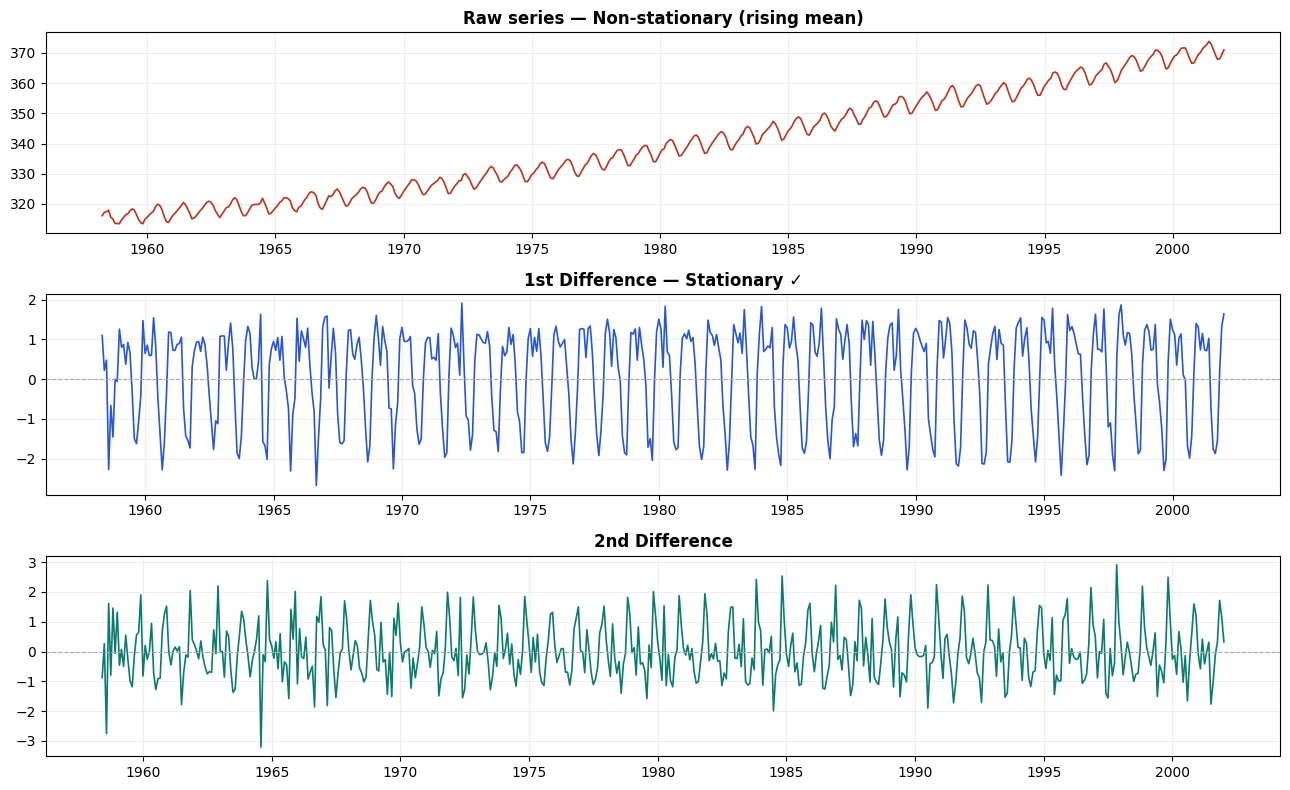

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=False)

axes[0].plot(co2['co2'],  color='#c0321b', lw=1.2)
axes[0].set_title('Raw series — Non-stationary (rising mean)', fontweight='bold')

axes[1].plot(co2_diff1,   color='#2856d4', lw=1.2)
axes[1].axhline(0, color='#aaa', lw=0.8, ls='--')
axes[1].set_title('1st Difference — Stationary ✓', fontweight='bold')

axes[2].plot(co2_diff2,   color='#0a7c6e', lw=1.2)
axes[2].axhline(0, color='#aaa', lw=0.8, ls='--')
axes[2].set_title('2nd Difference', fontweight='bold')

for ax in axes:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Lags
A lag is a past version of the series. Lag 1 = previous month. Lag 12 = same month last year.
Plotting the series against its lags reveals the autocorrelation structure.


First few rows showing lags:
               co2   lag_1   lag_6  lag_12  lag_24
1960-03-31  317.58  316.98  313.82  316.75  316.10
1960-04-30  319.12  317.58  313.40  317.68  317.20
1960-05-31  319.92  319.12  314.88  318.34  317.42
1960-06-30  319.45  319.92  315.52  318.02  317.90
1960-07-31  318.06  319.45  316.38  316.52  315.62
1960-08-31  315.77  318.06  316.98  314.90  314.96


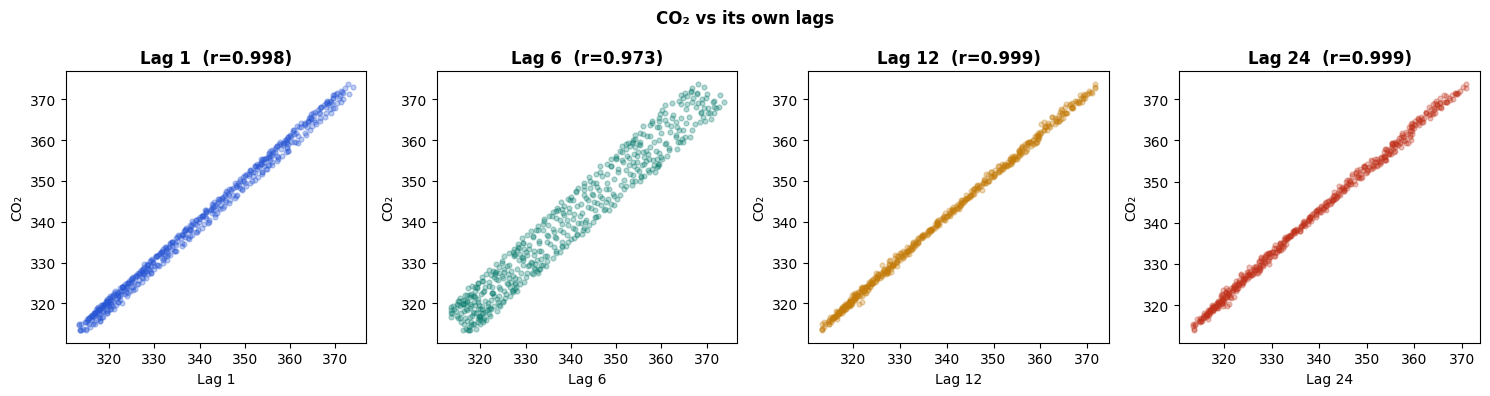

In [7]:
df_lags = pd.DataFrame({'co2': co2['co2']})
for lag in [1, 6, 12, 24]:
    df_lags[f'lag_{lag}'] = co2['co2'].shift(lag)

print('First few rows showing lags:')
print(df_lags.dropna().head(6).round(2))

# Scatter plots: series vs each lag
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
colors = ['#2856d4', '#0a7c6e', '#c47c0a', '#c0321b']

for ax, lag, c in zip(axes, [1, 6, 12, 24], colors):
    valid = df_lags[['co2', f'lag_{lag}']].dropna()
    corr  = valid['co2'].corr(valid[f'lag_{lag}'])
    ax.scatter(valid[f'lag_{lag}'], valid['co2'], alpha=0.3, s=12, color=c)
    ax.set_xlabel(f'Lag {lag}')
    ax.set_ylabel('CO₂')
    ax.set_title(f'Lag {lag}  (r={corr:.3f})', fontweight='bold')

plt.suptitle('CO₂ vs its own lags', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. ACF & PACF
Run on the **differenced** series — not the raw series (which isn't stationary).
- **ACF** → tells us q (MA order): lag where it cuts off
- **PACF** → tells us p (AR order): lag where it cuts off


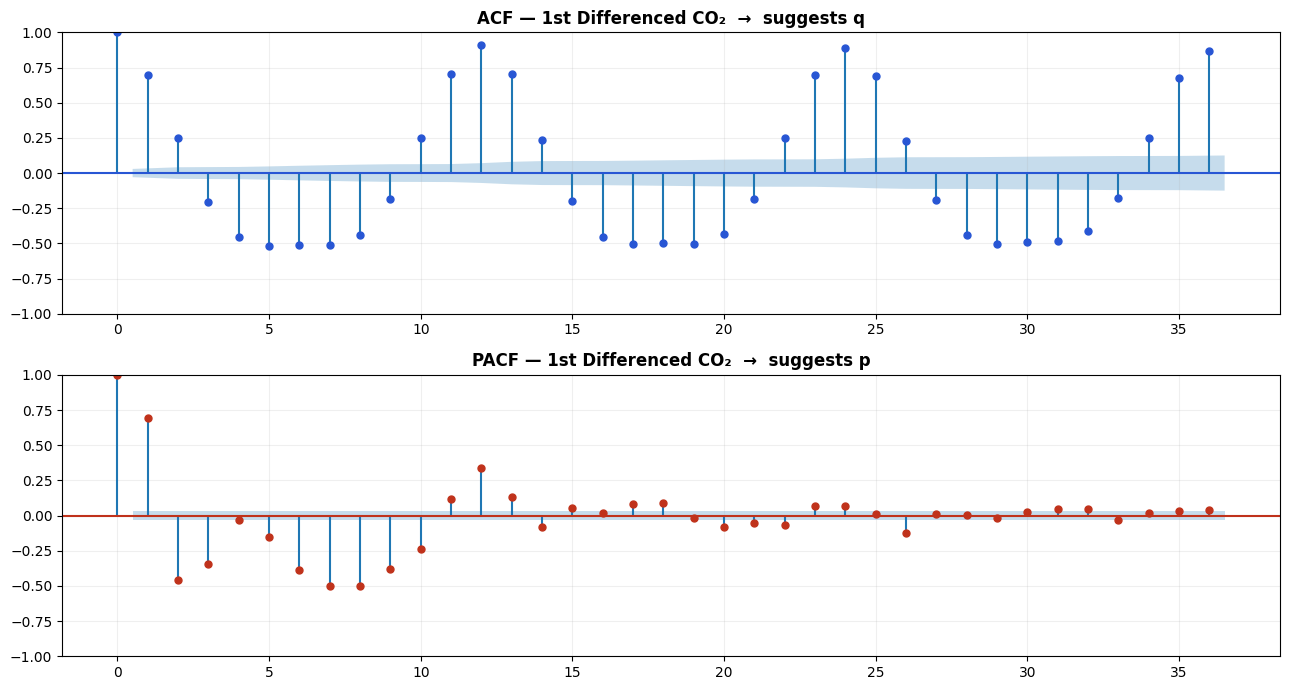

Reading the plots:
  ACF  — significant spikes at seasonal lags (12, 24) → seasonal MA component
  PACF — spike at lag 1, cuts off → AR(1) component
  Remaining seasonal pattern → ARIMA alone not enough → SARIMA needed


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

plot_acf(co2_diff1, lags=36, ax=ax1, color='#2856d4', alpha=0.5)
ax1.set_title('ACF — 1st Differenced CO₂  →  suggests q', fontweight='bold')
ax1.grid(True, alpha=0.2)

plot_pacf(co2_diff1, lags=36, ax=ax2, color='#c0321b', alpha=0.5)
ax2.set_title('PACF — 1st Differenced CO₂  →  suggests p', fontweight='bold')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print('Reading the plots:')
print('  ACF  — significant spikes at seasonal lags (12, 24) → seasonal MA component')
print('  PACF — spike at lag 1, cuts off → AR(1) component')
print('  Remaining seasonal pattern → ARIMA alone not enough → SARIMA needed')

## 7. Train / Test Split
Always split chronologically — never shuffle time series data.


In [9]:
# Use last 24 months as test set
train = co2.iloc[:-24]
test  = co2.iloc[-24:]

print(f'Train: {train.index[0].date()} to {train.index[-1].date()}  ({len(train)} months)')
print(f'Test : {test.index[0].date()}  to {test.index[-1].date()}   ({len(test)} months)')

Train: 1958-03-31 to 1999-12-31  (502 months)
Test : 2000-01-31  to 2001-12-31   (24 months)


## 8. ARIMA — Fit & Forecast
ARIMA(1,1,1): AR order=1, difference once, MA order=1.
ARIMA cannot handle seasonality — we'll see the limitation clearly.


In [10]:
arima_model  = ARIMA(train, order=(1, 1, 1))
arima_result = arima_model.fit()

print(f'AIC: {arima_result.aic:.2f}')
print(f'BIC: {arima_result.bic:.2f}')
print()
print(arima_result.summary().tables[1])

AIC: 1216.82
BIC: 1229.47

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5678      0.052     10.923      0.000       0.466       0.670
ma.L1          0.3212      0.058      5.551      0.000       0.208       0.435
sigma2         0.6553      0.046     14.101      0.000       0.564       0.746


ARIMA(1,1,1) — Test set performance
  MAE  : 1.658 ppm
  RMSE : 1.991 ppm
  MAPE : 0.447 %


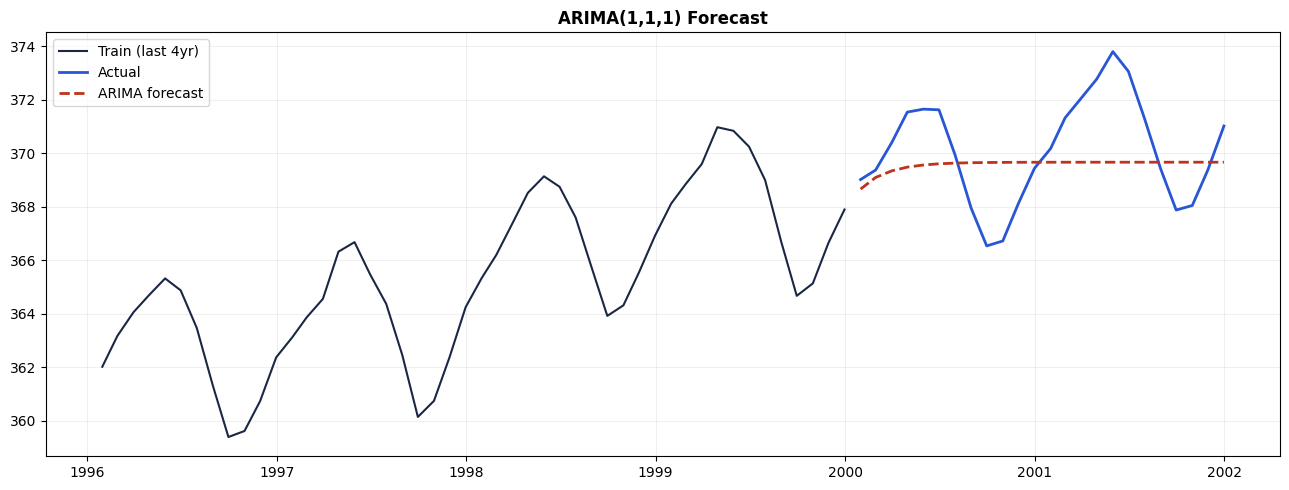


Note: ARIMA misses the seasonal pattern — the forecast is a flat drift.


In [11]:
arima_forecast = arima_result.forecast(steps=24)

mae_arima  = mean_absolute_error(test['co2'], arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test['co2'], arima_forecast))
mape_arima = np.mean(np.abs((test['co2'] - arima_forecast) / test['co2'])) * 100

print(f'ARIMA(1,1,1) — Test set performance')
print(f'  MAE  : {mae_arima:.3f} ppm')
print(f'  RMSE : {rmse_arima:.3f} ppm')
print(f'  MAPE : {mape_arima:.3f} %')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-48:], train['co2'].iloc[-48:], color='#1a2744', lw=1.5, label='Train (last 4yr)')
ax.plot(test.index,         test['co2'],             color='#2856d4',  lw=2,   label='Actual')
ax.plot(test.index,         arima_forecast,          color='#c0321b',  lw=2, ls='--', label='ARIMA forecast')
ax.set_title('ARIMA(1,1,1) Forecast', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('\nNote: ARIMA misses the seasonal pattern — the forecast is a flat drift.')

## 9. SARIMA — Adding Seasonality
SARIMA(1,1,1)(1,1,1,12) adds seasonal AR, differencing, and MA with period=12.
Watch how much better it captures the annual CO₂ cycle.


In [12]:
sarima_model  = SARIMAX(train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)
sarima_result = sarima_model.fit(disp=False)

print(f'AIC: {sarima_result.aic:.2f}')
print(f'BIC: {sarima_result.bic:.2f}')

AIC: 323.65
BIC: 344.61


SARIMA(1,1,1)(1,1,1,12) — Test set performance
  MAE  : 0.365 ppm
  RMSE : 0.437 ppm
  MAPE : 0.099 %


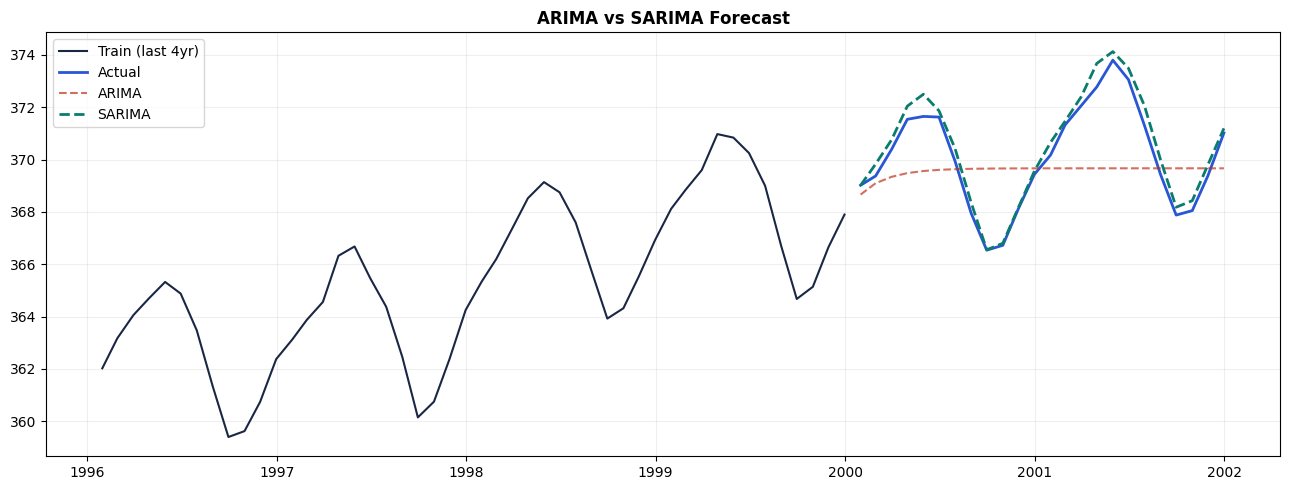

In [13]:
sarima_forecast = sarima_result.forecast(steps=24)

mae_sarima  = mean_absolute_error(test['co2'], sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test['co2'], sarima_forecast))
mape_sarima = np.mean(np.abs((test['co2'] - sarima_forecast) / test['co2'])) * 100

print(f'SARIMA(1,1,1)(1,1,1,12) — Test set performance')
print(f'  MAE  : {mae_sarima:.3f} ppm')
print(f'  RMSE : {rmse_sarima:.3f} ppm')
print(f'  MAPE : {mape_sarima:.3f} %')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-48:], train['co2'].iloc[-48:], color='#1a2744', lw=1.5, label='Train (last 4yr)')
ax.plot(test.index,         test['co2'],             color='#2856d4',  lw=2,   label='Actual')
ax.plot(test.index,         arima_forecast,          color='#c0321b',  lw=1.5, ls='--', label='ARIMA', alpha=0.7)
ax.plot(test.index,         sarima_forecast,         color='#0a7c6e',  lw=2,   ls='--', label='SARIMA')
ax.set_title('ARIMA vs SARIMA Forecast', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Residual Diagnostics — SARIMA
Good model residuals should look like white noise — no patterns remaining.


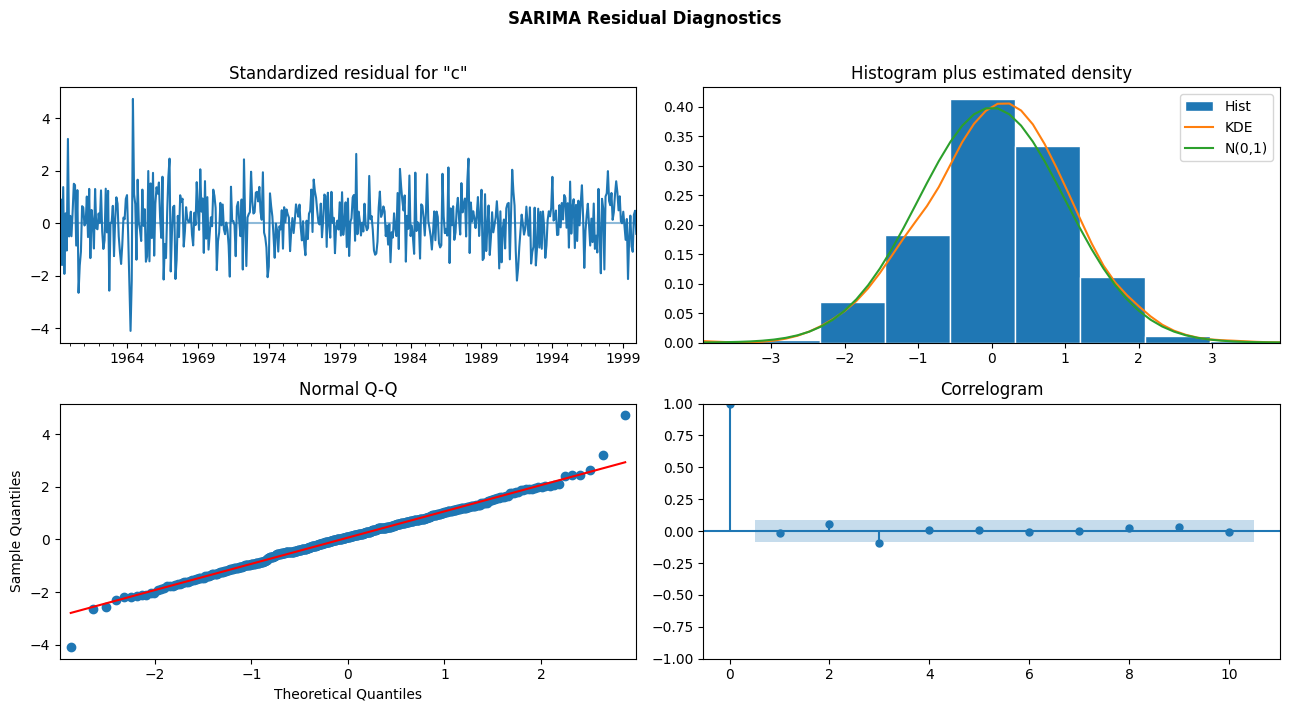

What to check:
  Top-left   : Residuals should look random (no patterns)
  Top-right  : Histogram + KDE should be close to N(0,1)
  Bottom-left: Q-Q plot — points should follow the diagonal
  Bottom-right: Correlogram — no significant spikes outside confidence band


In [14]:
fig = sarima_result.plot_diagnostics(figsize=(13, 7))
plt.suptitle('SARIMA Residual Diagnostics', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('What to check:')
print('  Top-left   : Residuals should look random (no patterns)')
print('  Top-right  : Histogram + KDE should be close to N(0,1)')
print('  Bottom-left: Q-Q plot — points should follow the diagonal')
print('  Bottom-right: Correlogram — no significant spikes outside confidence band')

## 11. Prophet — Fit & Forecast
Prophet requires a DataFrame with columns `ds` (dates) and `y` (values).
No stationarity needed, no ACF/PACF — Prophet handles it automatically.


In [15]:
from prophet import Prophet

# Prepare Prophet format
train_prophet = train.reset_index().rename(columns={'index':'ds', 'co2':'y'})
test_prophet  = test.reset_index().rename(columns={'index':'ds', 'co2':'y'})

# Fit
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        daily_seasonality=False)
prophet_model.fit(train_prophet)

# Forecast
future        = prophet_model.make_future_dataframe(periods=24, freq='ME')
prophet_fc    = prophet_model.predict(future)

prophet_test_fc = prophet_fc[prophet_fc['ds'].isin(test.index)]['yhat'].values

mae_prophet  = mean_absolute_error(test['co2'], prophet_test_fc)
rmse_prophet = np.sqrt(mean_squared_error(test['co2'], prophet_test_fc))
mape_prophet = np.mean(np.abs((test['co2'].values - prophet_test_fc) / test['co2'].values)) * 100

print('Prophet — Test set performance')
print(f'  MAE  : {mae_prophet:.3f} ppm')
print(f'  RMSE : {rmse_prophet:.3f} ppm')
print(f'  MAPE : {mape_prophet:.3f} %')

Importing plotly failed. Interactive plots will not work.
13:34:46 - cmdstanpy - INFO - Chain [1] start processing
13:34:49 - cmdstanpy - INFO - Chain [1] done processing


Prophet — Test set performance
  MAE  : 0.230 ppm
  RMSE : 0.268 ppm
  MAPE : 0.062 %


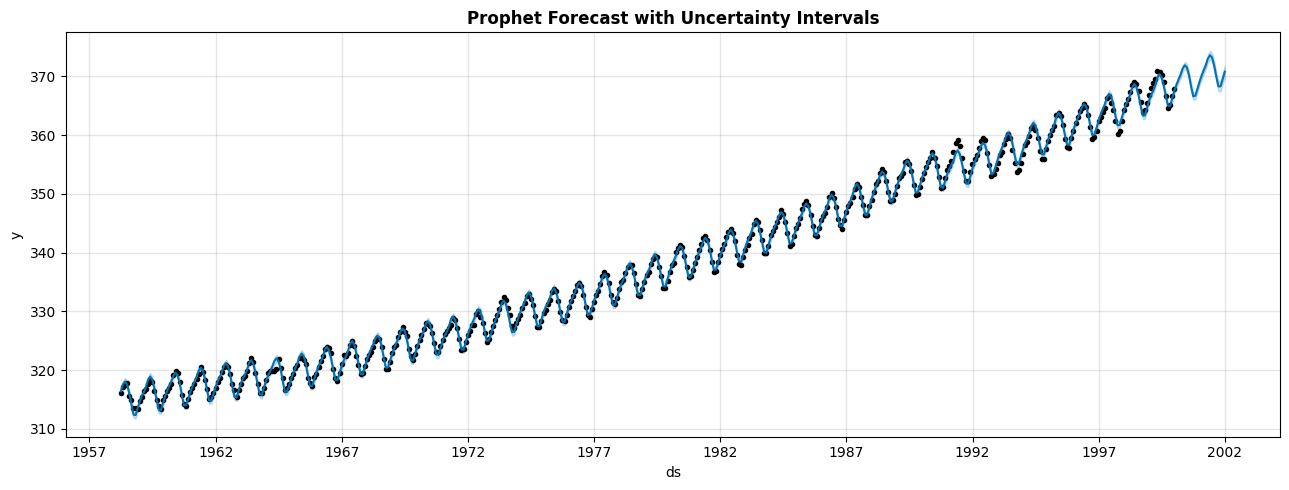

In [16]:
# Prophet's built-in plot
fig = prophet_model.plot(prophet_fc, figsize=(13, 5))
plt.title('Prophet Forecast with Uncertainty Intervals', fontweight='bold')
plt.tight_layout()
plt.show()

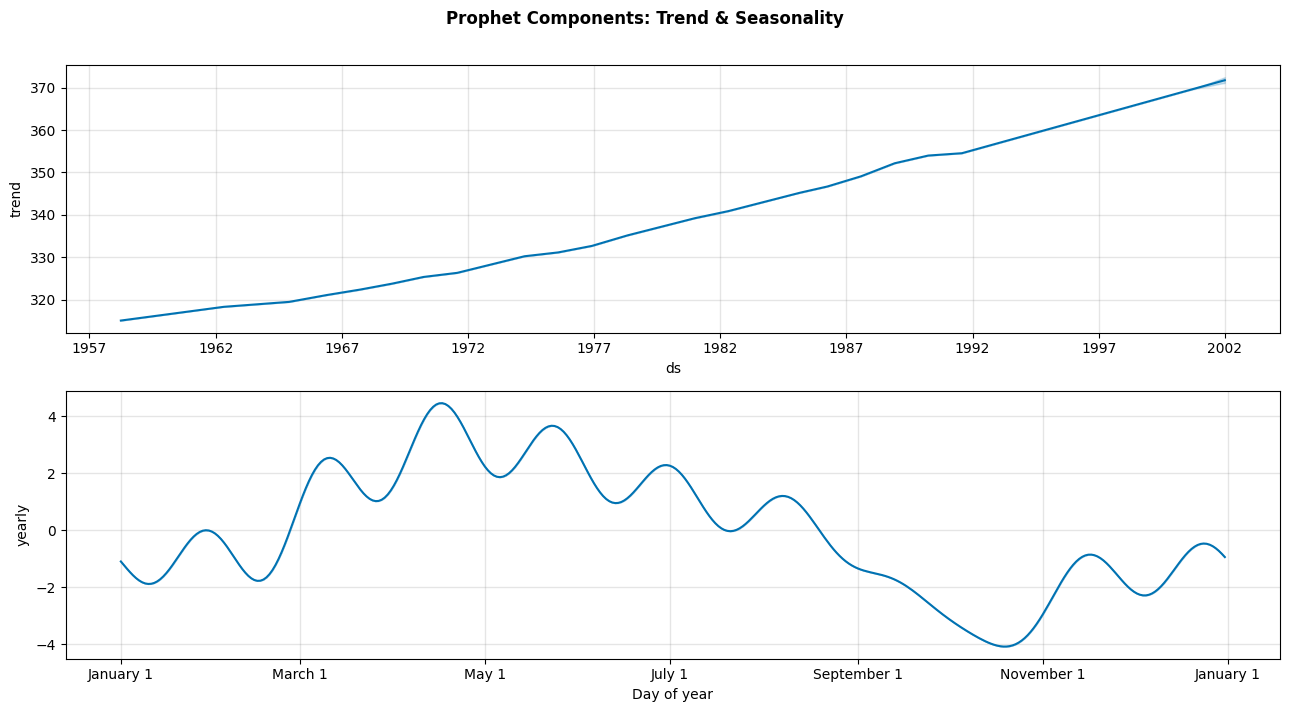

In [17]:
# Component decomposition — trend + seasonality separated
fig = prophet_model.plot_components(prophet_fc, figsize=(13, 7))
plt.suptitle('Prophet Components: Trend & Seasonality', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 12. Model Comparison


In [18]:
# Naive forecast: last value repeated
naive_forecast = np.full(24, train['co2'].iloc[-1])
mae_naive  = mean_absolute_error(test['co2'], naive_forecast)
rmse_naive = np.sqrt(mean_squared_error(test['co2'], naive_forecast))
mape_naive = np.mean(np.abs((test['co2'].values - naive_forecast) / test['co2'].values)) * 100

results = pd.DataFrame([
    {'Model': 'Naïve (baseline)',           'MAE': mae_naive,   'RMSE': rmse_naive,  'MAPE(%)': mape_naive},
    {'Model': 'ARIMA(1,1,1)',               'MAE': mae_arima,   'RMSE': rmse_arima,  'MAPE(%)': mape_arima},
    {'Model': 'SARIMA(1,1,1)(1,1,1,12)',   'MAE': mae_sarima,  'RMSE': rmse_sarima, 'MAPE(%)': mape_sarima},
    {'Model': 'Prophet',                    'MAE': mae_prophet, 'RMSE': rmse_prophet,'MAPE(%)': mape_prophet},
]).round(4)

print(results.to_string(index=False))
print()
print('Lower MAE / RMSE / MAPE = better forecast')

                  Model    MAE   RMSE  MAPE(%)
       Naïve (baseline) 2.4202 2.9291   0.6518
           ARIMA(1,1,1) 1.6579 1.9909   0.4474
SARIMA(1,1,1)(1,1,1,12) 0.3655 0.4371   0.0986
                Prophet 0.2301 0.2684   0.0622

Lower MAE / RMSE / MAPE = better forecast


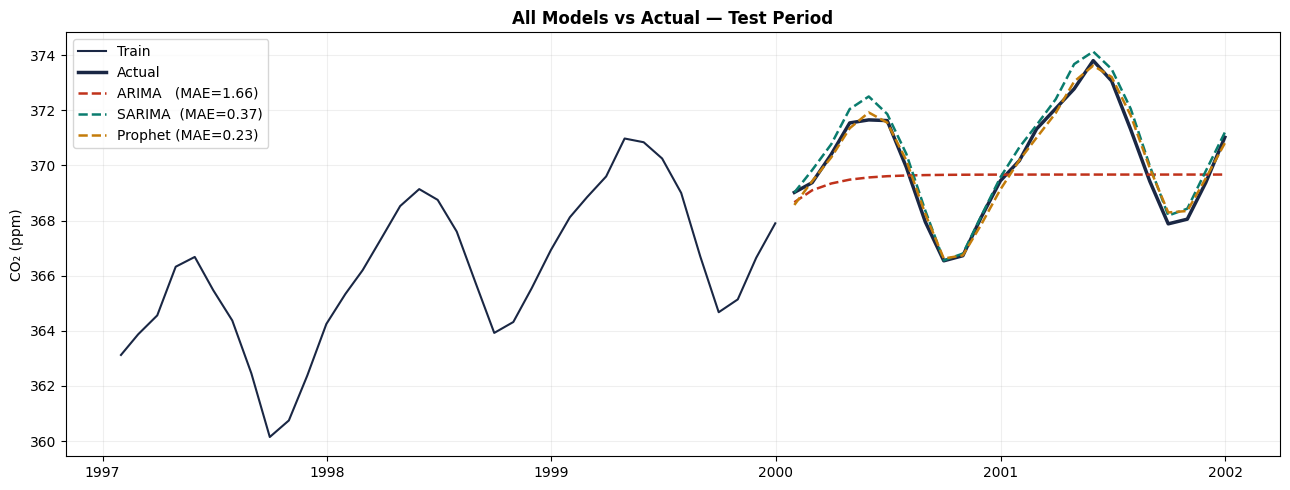

In [19]:
# Final visual comparison on test period
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index[-36:], train['co2'].iloc[-36:], color='#1a2744', lw=1.5, label='Train')
ax.plot(test.index, test['co2'],            color='#1a2744',  lw=2.5, label='Actual')
ax.plot(test.index, arima_forecast,         color='#c0321b',  lw=1.8, ls='--', label=f'ARIMA   (MAE={mae_arima:.2f})')
ax.plot(test.index, sarima_forecast,        color='#0a7c6e',  lw=1.8, ls='--', label=f'SARIMA  (MAE={mae_sarima:.2f})')
ax.plot(test.index, prophet_test_fc,        color='#c47c0a',  lw=1.8, ls='--', label=f'Prophet (MAE={mae_prophet:.2f})')
ax.set_title('All Models vs Actual — Test Period', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.2)
ax.set_ylabel('CO₂ (ppm)')
plt.tight_layout()
plt.show()

## Summary

| Step | What we did | Key takeaway |
|---|---|---|
| Decomposition | Split into trend, seasonal, residual | CO₂ has ~7.5 ppm annual swing on top of a rising trend |
| ADF test | Checked for stationarity | Raw series non-stationary (p≈1.0) → need d=1 |
| Differencing | Removed trend | 1st difference passes ADF (p<0.05) |
| Lags | Plotted series vs past values | Lag 1 and Lag 12 show strong correlation |
| ACF/PACF | Chose p and q | Seasonal spikes at 12, 24 → SARIMA needed |
| ARIMA | Fitted (1,1,1) | Misses seasonality — flat forecast drift |
| SARIMA | Fitted (1,1,1)(1,1,1,12) | Captures both trend and annual cycle |
| Prophet | Fitted additive model | Competitive accuracy, interpretable components |

---
**Next:** Forecasting metrics deep-dive and Exponential Smoothing
